## Run DOLPHOT on simulated Rosesim images and do artificial star injection tests

In [214]:
# Import packages
%load_ext autoreload
%autoreload 2

import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import os
from astropy.io import fits
from kuaizi.display import display_single

import romanisim
import romanisim.parameters
import romanisim.bandpass
from astropy.table import Table, hstack, vstack
import astropy.units as u

import sys
sys.path.append('/home/jiaxuanl/Research/SALAD/script/')
from display import show_image_wcs

from scipy.stats import binned_statistic
import kuaizi
kuaizi.set_matplotlib(style='nature', usetex=False, dpi=90)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Check DOLPHOT residuals

In [215]:
exptime = 5136
host = 'cena'

In [216]:
os.chdir(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/DOLPHOT/{host}/')
!pwd

/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/DOLPHOT/cena


(<Figure size 900x360 with 2 Axes>,
 <Axes: >,
 {'norm': <astropy.visualization.mpl_normalize.ImageNormalize at 0x7fc35de99e50>})

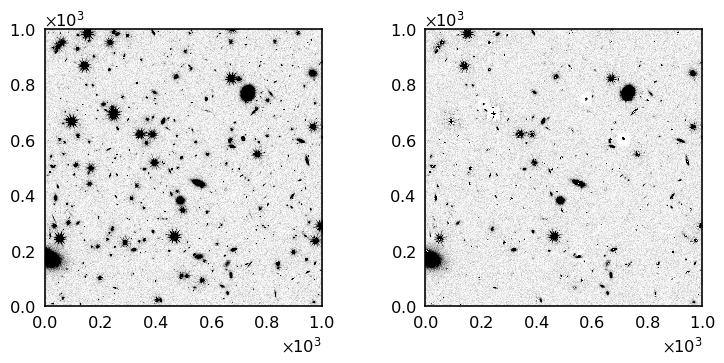

In [217]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10, 4))

hdu = fits.open(f'./F158_{exptime}s.fits')
_, _, norm = show_image_wcs(hdu[0].data[:1000, :1000], fig=fig, ax=ax1, percl=97)

# The residual image after DOLPHOT. You'll see lots of point sources disappeared.
hdu = fits.open(f'./{host}_{exptime}s/{host}_{exptime}s.phot.2.res.fits')
show_image_wcs(hdu[0].data[:1000, :1000], fig=fig, ax=ax2, scale_args=norm)

In [218]:
# fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10, 4))

# exptime = 10272
# # hdu = fits.open(f'../raw/F158_{exptime}s.fits')
# hdu = fits.open(f'./F158_{exptime}s.fits')
# _, _, norm = show_image_wcs(hdu[0].data[:1000, :1000], fig=fig, ax=ax1)#, percl=93)

# # hdu = fits.open(f'./F158_{exptime}s.fits')
# hdu = fits.open(f'./ngc253_{exptime}s/ngc253_{exptime}s.phot.1.res.fits')
# show_image_wcs(hdu[0].data[:1000, :1000], fig=fig, ax=ax2)#, scale_args=norm)

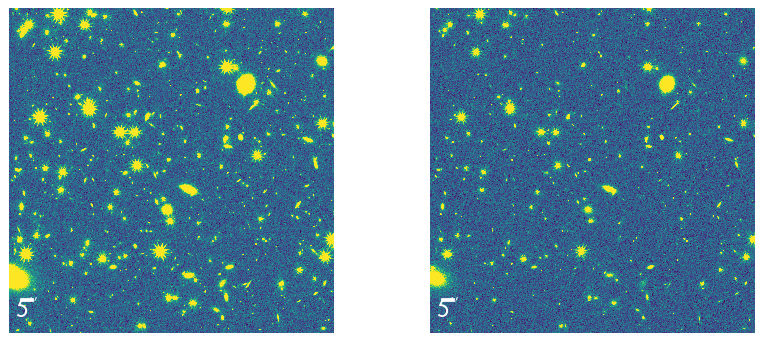

In [219]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10, 4))
exptime = 5136
hdu = fits.open(f'./raw/F158_{exptime}s.fits')
display_single(hdu[0].data[:1000, :1000], ax=ax1);

exptime = 642
hdu = fits.open(f'./raw/F158_{exptime}s.fits')
display_single(hdu[0].data[:1000, :1000], ax=ax2);

plt.tight_layout()

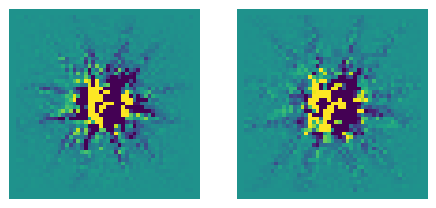

In [220]:
# This shows the "correction" term to the fiducial Roman PSF templates, as we downloaded when installing DOLPHOT
exptime = 642
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(6, 3))
hdu = fits.open(f'{host}_{exptime}s.phot.1.psf.fits')
display_single(hdu[0].data, xsize=4, ysize=4, scale_bar=False, ax=ax1);
hdu = fits.open(f'{host}_{exptime}s.phot.2.psf.fits')
display_single(hdu[0].data, xsize=4, ysize=4, scale_bar=False, ax=ax2);

## 2. Check the DOLPHOT catalog

In [221]:
from rosesim.utils import read_dolphot_cat, xmatch_true_meas


def quality_cut(cat, snr=5, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03}):
    flag = cat['snr_f158'] > snr
    flag &= cat['snr_f106'] > snr
    flag &= (cat['crowd_f106'] < crowd['f106'])
    flag &= (cat['crowd_f158'] < crowd['f158'])
    flag &= (cat['qflag_f158'] <= 4)
    flag &= (cat['qflag_f106'] <= 4)
    flag &= (cat['obj_type'] <= 2)
    flag &= (cat['pass_det'] < 3)
    return flag


def point_source_cut(cat, snr=5, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03}):
    flag = quality_cut(cat, snr=snr, crowd=crowd, sharp=sharp)
    flag &= (cat['sharp_f106']**2 < sharp['f106'])
    flag &= (cat['sharp_f158']**2 < sharp['f158'])
    flag &= (cat['chi_f106'] < 3)
    flag &= (cat['chi_f158'] < 3)
    return flag

Exptime: 5136.0 Filters: ['F106', 'F158']


Text(0, 0.5, 'sharp')

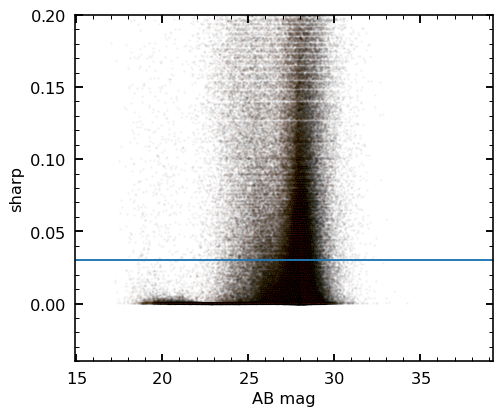

In [222]:
exptime = 5136
os.chdir(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/DOLPHOT/{host}/')
cat = read_dolphot_cat(f'./{host}_{exptime}s.phot', f'./{host}_{exptime}s.phot.columns', fake=False)

plt.scatter(cat['mag_ab_f106'], abs(cat['sharp_f106'])**2, s=1, alpha=0.04)
plt.scatter(cat['mag_ab_f158'], abs(cat['sharp_f158'])**2, s=1, alpha=0.04)
plt.ylim(-0.04, 0.2)
plt.axhline(0.03)
plt.xlabel('AB mag')
plt.ylabel('sharp')

In [223]:
cat['good_flag'] = quality_cut(cat, snr=3, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03})

cat['star_flag'] = point_source_cut(cat, snr=3, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.01, 'f106': 0.03})

In [224]:
np.sum(cat['star_flag']), np.sum(cat['good_flag'])

(np.int64(12605), np.int64(58912))

In [225]:
from astropy.wcs import WCS
w = WCS(fits.open(f'./F158_{exptime}s.fits')[0].header)
cat['ra'], cat['dec'] = w.all_pix2world(cat['x'], cat['y'], 1)
cat[:3]

ext,chip,x,y,chi,snr,sharp,round,major_axis,crowd,obj_type,pass_det,counts_f106,sky_f106,mag_ab_f106,mag_err_f106,chi_f106,snr_f106,sharp_f106,round_f106,crowd_f106,qflag_f106,counts_f158,sky_f158,mag_ab_f158,mag_err_f158,chi_f158,snr_f158,sharp_f158,round_f158,crowd_f158,qflag_f158,good_flag,star_flag,ra,dec
int64,int64,float64,float64,float64,float64,float64,float64,int64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,bool,bool,float64,float64
0,1,3527.77,3738.59,0.0,524.8,-0.832,0.194,75,0.099,1,1,27400000.0,4998.06,17.033924091939536,0.002,1.0,472.1,-0.93,0.198,0.109,12,27500000.0,7540.41,17.047657605320843,0.005,1.0,229.2,-0.425,0.175,0.057,12,False,False,201.41329911120152,-42.978843451456946
0,1,2428.0,3108.24,0.0,257.7,-0.745,1.714,160,0.405,1,1,19200000.0,12372.65,17.420047427231633,0.006,1.0,187.0,-0.689,2.119,0.419,12,50200000.0,15197.6,16.394230047033954,0.006,1.0,177.4,-0.904,0.539,0.366,12,False,False,201.3673661940049,-42.998112104605724
0,1,2441.38,3098.77,0.0,270.8,-1.705,0.89,160,0.323,1,1,19500000.0,21967.85,17.40321397058421,0.005,1.0,237.4,-1.0,0.942,0.341,12,70200000.0,28108.06,16.03014655957199,0.008,1.0,130.1,-9.999,0.261,0.108,12,False,False,201.36792517410908,-42.998401479167626


In [226]:
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table, hstack

def xmatch_true_to_meas(true_cat, cat, radius=0.2*u.arcsec,
                        true_ra='ra', true_dec='dec',
                        meas_ra='ra', meas_dec='dec',
                        true_prefix='true_', meas_prefix='meas_'):
    """
    For each obj in truth catalog, find the nearest measured obj within `radius`.
    If none exists, fill measured columns with NaN.

    Returns
    -------
    out : astropy.table.Table
        One row per true object. Contains:
          - all true_* columns
          - all meas_* columns (NaN if unmatched)
          - sep_arcsec (NaN if unmatched)
          - matched (bool)
          - meas_index (int; -1 if unmatched)  [index in original `cat`]
    """

    # SkyCoords
    c_true = SkyCoord(true_cat[true_ra], true_cat[true_dec], unit='deg')
    c_meas = SkyCoord(cat[meas_ra], cat[meas_dec], unit='deg')

    # For each true source, find nearest measured source
    idx_meas, d2d, _ = c_true.match_to_catalog_sky(c_meas)  # length = len(true_cat)

    matched = d2d < radius
    sep_arcsec = np.full(len(true_cat), np.nan, dtype=float)
    sep_arcsec[matched] = d2d[matched].to_value(u.arcsec)

    # Prepare output tables (one row per true object)
    true_out = true_cat.copy()
    true_out.rename_columns(true_out.colnames, [true_prefix + c for c in true_out.colnames])

    # Build measured-out table with same length as truth
    meas_out = Table()
    for col in cat.colnames:
        name = meas_prefix + col
        dtype_kind = cat[col].dtype.kind

        if dtype_kind in ('U', 'S', 'O'):  # strings / objects
            # safest: use masked column so missing values are well-defined
            mcol = cat[col].copy()
            mcol = np.ma.masked_all(len(true_cat), dtype=cat[col].dtype)
            meas_out[name] = mcol
        else:
            # numeric: NaN works (including ints -> cast to float)
            arr = np.full(len(true_cat), np.nan, dtype=float)
            meas_out[name] = arr

    # Fill measured columns for matched rows
    if np.any(matched):
        rows = idx_meas[matched]
        for col in cat.colnames:
            name = meas_prefix + col
            dtype_kind = cat[col].dtype.kind
            if dtype_kind in ('U', 'S', 'O'):
                meas_out[name][matched] = cat[col][rows]
                meas_out[name].mask[matched] = False
            else:
                meas_out[name][matched] = np.asarray(cat[col][rows], dtype=float)

    out = hstack([true_out, meas_out], join_type='exact')
    out['sep_arcsec'] = sep_arcsec
    out['matched'] = matched
    out['meas_index'] = np.where(matched, idx_meas, -1).astype(int)

    return out

In [227]:
from astropy.coordinates import SkyCoord
# true_cat = Table.read('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/gal_28mag/temp/sky_table.ecsv')
# true_cat = Table.read('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/temp/sky_table_sky_jaguar_trilegal_ngc253.ecsv')
true_cat = Table.read(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_cena/temp/sky_table_sky_jaguar_trilegal_cena.ecsv')
# true_cat = true_cat[true_cat['type'] == 'PSF']
out = xmatch_true_to_meas(true_cat, cat, radius=0.3 * u.arcsec)

In [206]:
np.sum(out['meas_index'] != -1)

np.int64(57849)

In [167]:
len(true_cat), len(out), len(cat), out['matched'].sum()

(96337, 96337, 83580, np.int64(29904))

In [207]:
len(true_cat), len(out), len(cat), out['matched'].sum()

(101034, 101034, 151662, np.int64(57849))

(-0.04, 0.5)

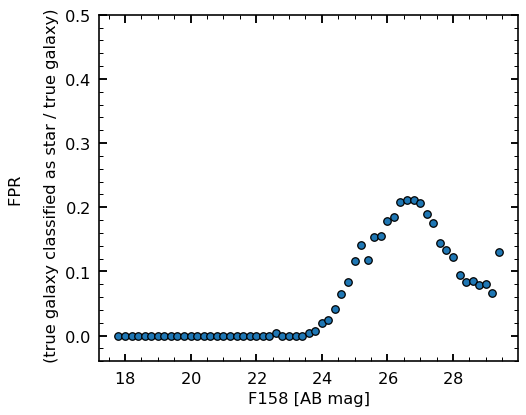

In [208]:
flag = out['matched']

comp_bins = np.arange(17.5, 29.6, 0.2)
res = binned_statistic(-2.5 * np.log10(out[flag]['true_F158']), 
                       (out[flag]['true_type'] == 'SER'), 
                       bins=comp_bins, statistic='sum')
mag = 0.5 * (res.bin_edges[:-1] + res.bin_edges[1:])
N = res.statistic

res = binned_statistic(-2.5 * np.log10(out[flag]['true_F158']), 
                       ((out['meas_star_flag'] == 1.0) & (out['true_type'] == 'SER'))[flag], 
                       bins=comp_bins, statistic='sum')
mag = 0.5 * (res.bin_edges[:-1] + res.bin_edges[1:])
FP = res.statistic

plt.scatter(mag, FP / N)

plt.xlabel('F158 [AB mag]')
plt.ylabel('FPR \n\n (true galaxy classified as star / true galaxy)')

plt.ylim(-0.04, 0.5)

(-0.04, 0.5)

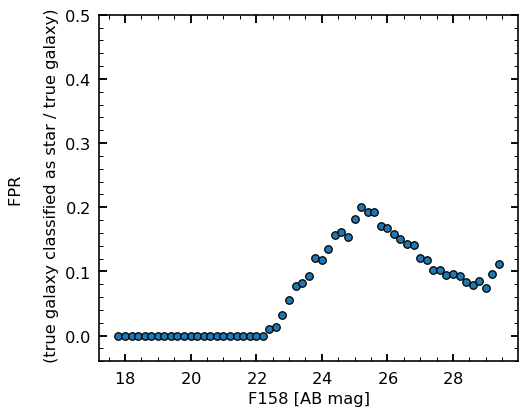

In [168]:
flag = out['matched']

comp_bins = np.arange(17.5, 29.6, 0.2)
res = binned_statistic(-2.5 * np.log10(out[flag]['true_F158']), 
                       (out[flag]['true_type'] == 'SER'), 
                       bins=comp_bins, statistic='sum')
mag = 0.5 * (res.bin_edges[:-1] + res.bin_edges[1:])
N = res.statistic

res = binned_statistic(-2.5 * np.log10(out[flag]['true_F158']), 
                       ((out['meas_star_flag'] == 1.0) & (out['true_type'] == 'SER'))[flag], 
                       bins=comp_bins, statistic='sum')
mag = 0.5 * (res.bin_edges[:-1] + res.bin_edges[1:])
FP = res.statistic

plt.scatter(mag, FP / N)

plt.xlabel('F158 [AB mag]')
plt.ylabel('FPR \n\n (true galaxy classified as star / true galaxy)')

plt.ylim(-0.04, 0.5)

In [209]:
flag = out['matched']

comp_bins = np.arange(17.5, 29.6, 0.2)
res = binned_statistic(-2.5 * np.log10(out[flag]['true_F158']), 
                       (out[flag]['true_type'] == 'PSF'), 
                       bins=comp_bins, statistic='sum')
mag = 0.5 * (res.bin_edges[:-1] + res.bin_edges[1:])
P = res.statistic

res = binned_statistic(-2.5 * np.log10(out[flag]['true_F158']), 
                       ((out['meas_star_flag'] == 1.0) & (out['true_type'] == 'PSF'))[flag], 
                       bins=comp_bins, statistic='sum')
mag = 0.5 * (res.bin_edges[:-1] + res.bin_edges[1:])
TP = res.statistic

Text(0, 0.5, 'TPR \n\n (true galaxy classified as star / true galaxy)')

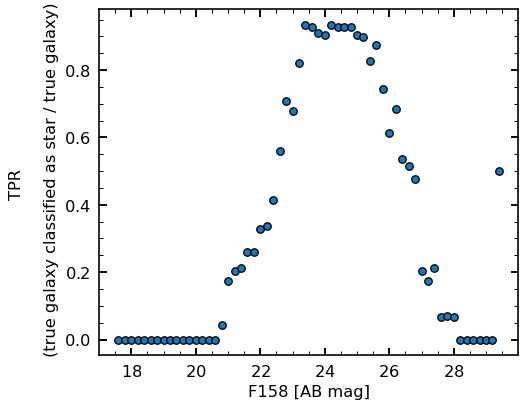

In [210]:
plt.scatter(mag, TP / P)

plt.xlabel('F158 [AB mag]')
plt.ylabel('TPR \n\n (true galaxy classified as star / true galaxy)')

# plt.ylim(-0.04, 0.5)

(0.0, 1.1)

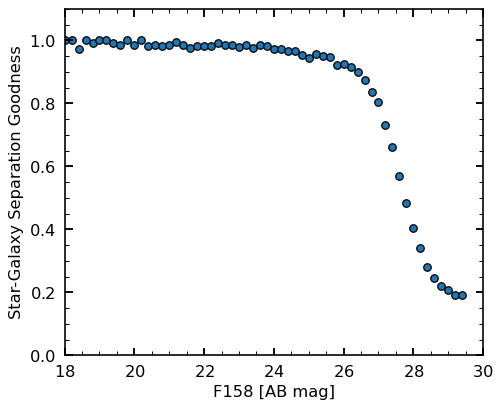

In [211]:
comp_bins = np.arange(17.5, 29.6, 0.2)
res = binned_statistic(-2.5 * np.log10(out['true_F158']), 
                       out['matched'], 
                       bins=comp_bins, statistic='mean')
mag, comp = 0.5 * (res.bin_edges[:-1] + res.bin_edges[1:]), res.statistic
plt.scatter(mag, comp)

plt.ylabel('Star-Galaxy Separation Goodness')
plt.xlabel('F158 [AB mag]')

plt.xlim(18, 30)
plt.ylim(0, 1.1)

(0.0, 1.1)

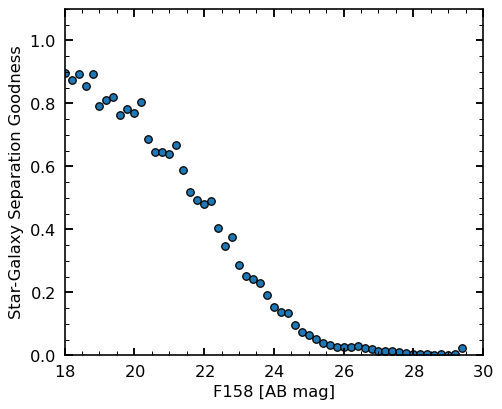

In [212]:
comp_bins = np.arange(17.5, 29.6, 0.2)
res = binned_statistic(-2.5 * np.log10(out['true_F158']), 
                       out['true_type'] == 'PSF', 
                       bins=comp_bins, statistic='mean')
mag, comp = 0.5 * (res.bin_edges[:-1] + res.bin_edges[1:]), res.statistic
plt.scatter(mag, comp)

plt.ylabel('Star-Galaxy Separation Goodness')
plt.xlabel('F158 [AB mag]')

plt.xlim(18, 30)
plt.ylim(0, 1.1)

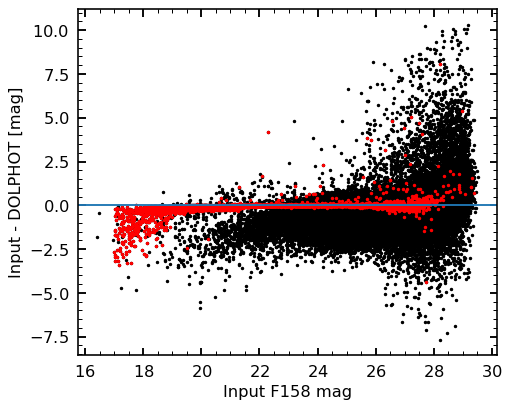

In [213]:
plt.scatter(-2.5 * np.log10(out['true_F158']), -2.5 * np.log10(out['true_F158']) - out['meas_mag_ab_f158'], s=3, color='k')

flag = out['true_type'] == 'PSF'
plt.scatter(-2.5 * np.log10(out[flag]['true_F158']), 
            -2.5 * np.log10(out[flag]['true_F158']) - out[flag]['meas_mag_ab_f158'], s=3, color='r')

# plt.ylim(-0.4, 0.4)

plt.xlabel('Input F158 mag')
plt.ylabel('Input - DOLPHOT [mag]')
plt.axhline(0)

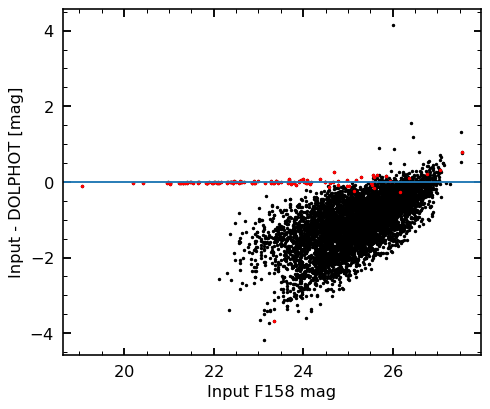

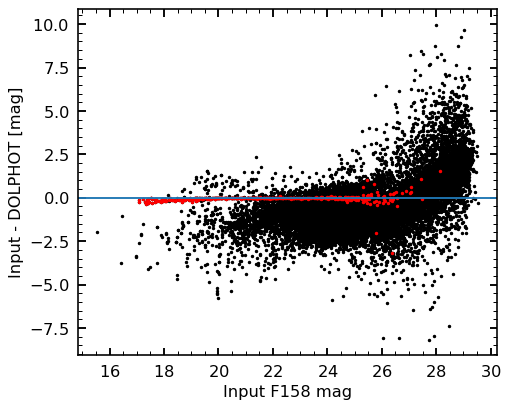

In [175]:
plt.scatter(-2.5 * np.log10(out['true_F158']), -2.5 * np.log10(out['true_F158']) - out['meas_mag_ab_f158'], s=3, color='k')

flag = out['true_type'] == 'PSF'
plt.scatter(-2.5 * np.log10(out[flag]['true_F158']), 
            -2.5 * np.log10(out[flag]['true_F158']) - out[flag]['meas_mag_ab_f158'], s=3, color='r')

# plt.ylim(-0.4, 0.4)

plt.xlabel('Input F158 mag')
plt.ylabel('Input - DOLPHOT [mag]')
plt.axhline(0)